# Практичне завдання 2 — Логістична регресія та федеративне навчання

**Мета:** дослідити багатокласову логістичну регресію, реалізувати її засобами NumPy та дослідити FedAvg на IID і Non-IID даних.



In [6]:
# Імпорти та налаштування
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    log_loss, confusion_matrix, classification_report
)
from sklearn.feature_selection import f_classif

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("Environment ready")


Environment ready


## 1. Завантаження та первинний аналіз даних

Dry Bean Dataset містить 16 числових фізичних характеристик зерен і цільову змінну `Class` з 7 сортами квасолі. У наборі немає пропущених значень. 


In [5]:

import pandas as pd

df = pd.read_excel("Dry_Bean_Dataset.xlsx")

print("Shape:", df.shape)

display(df.head())

display(df.dtypes.to_frame("dtype"))

Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


,dtype
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRation,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


In [7]:
# EDA: пропуски, класи та основні статистики
print("Missing values:")
display(df.isna().sum().to_frame("missing"))

print("Class distribution:")
class_counts = df["Class"].value_counts()
display(class_counts.to_frame("count"))

display(df.describe().T)


Missing values:


,missing
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


Class distribution:


,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


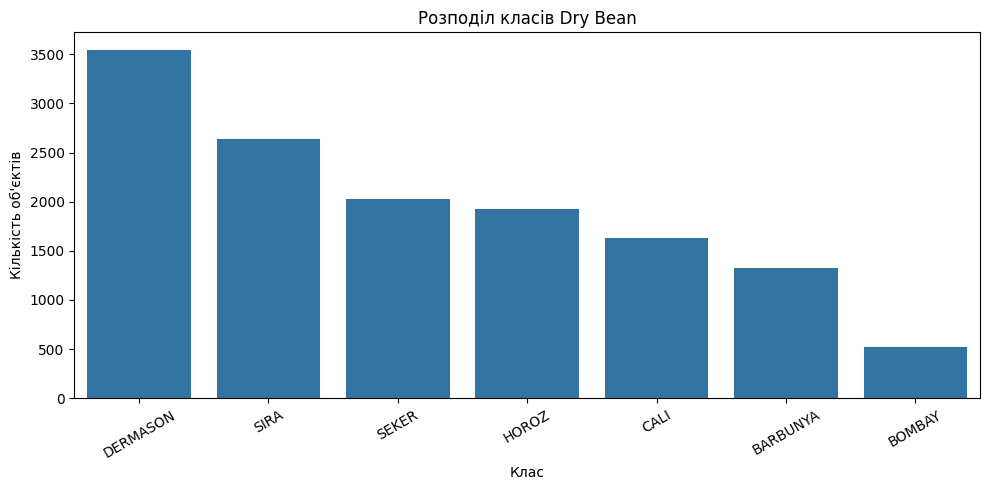

In [8]:
# Візуалізація розподілу класів
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Розподіл класів Dry Bean")
plt.xlabel("Клас")
plt.ylabel("Кількість об'єктів")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Висновок EDA.** Датасет підходить для федеративного навчання: він достатньо великий для розподілу між кількома клієнтами, має 7 класів і 16 числових ознак. Відсутність пропущених значень спрощує попередню обробку. Класи мають різну кількість прикладів, тому доцільно контролювати баланс через stratified split та використовувати `macro-F1` і `balanced accuracy`.


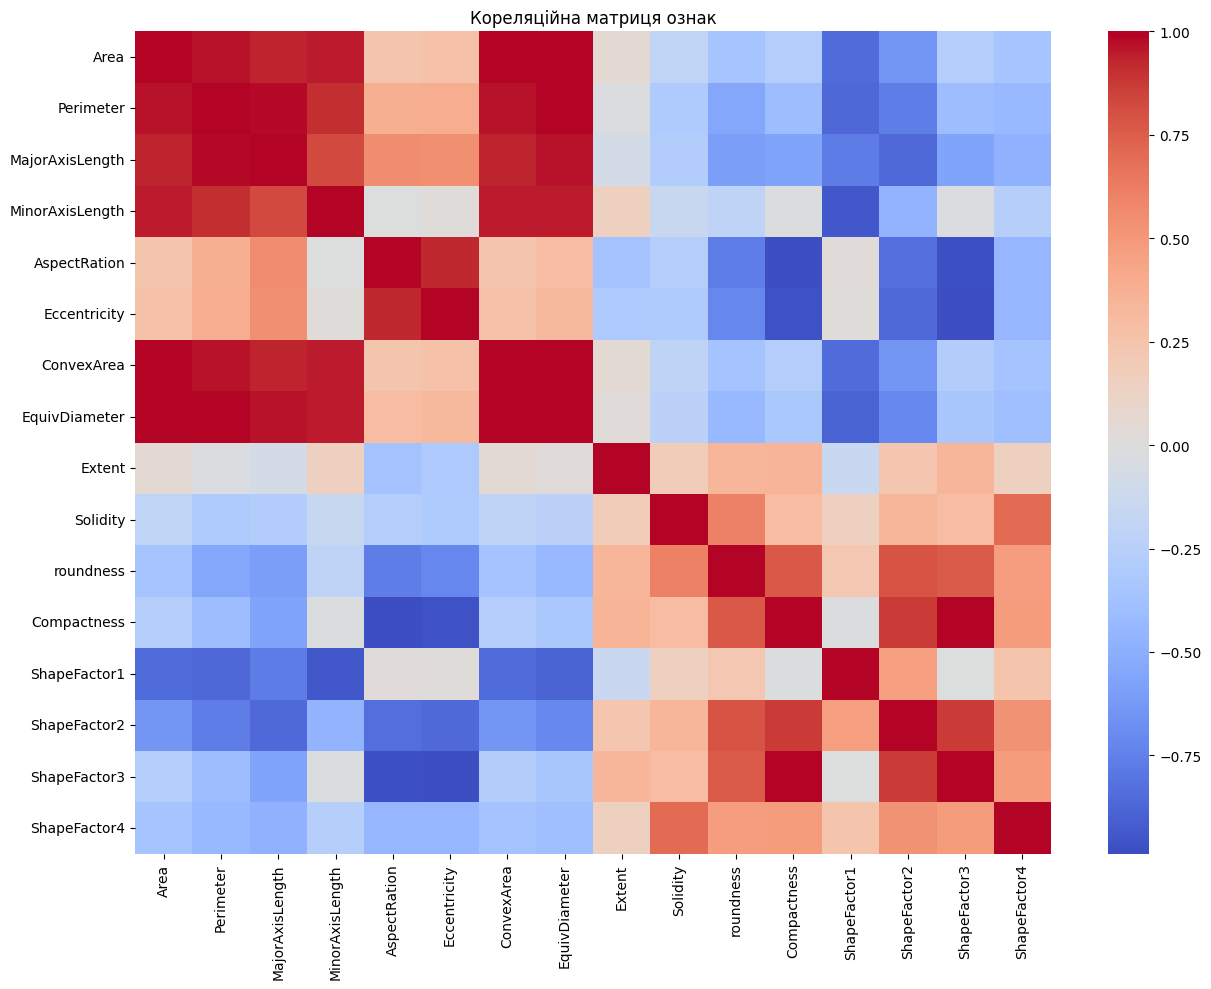

In [9]:
# Кореляційний аналіз числових ознак
feature_cols = [c for c in df.columns if c != "Class"]
corr = df[feature_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Кореляційна матриця ознак")
plt.tight_layout()
plt.show()


## 2. Розбиття даних без Data Leakage

Спочатку формуються `Global Test`, `Global Validation` і `FL Train Pool`, а вже потім виконуються операції, параметри яких навчаються на даних: відбір ознак і масштабування.

У цій роботі використано:
- **Global Test - 20%**;
- **Global Validation - 12%** від повного набору;
- **FL Train Pool - 68%**.

Global Test не використовується ні для підбору гіперпараметрів, ні для навчання. Це відповідає вимогам методички. 


In [10]:

X_raw = df[feature_cols].astype(float).to_numpy()
y_raw = df["Class"].to_numpy()

classes = np.unique(y_raw)
class_to_id = {c: i for i, c in enumerate(classes)}
y = np.array([class_to_id[v] for v in y_raw], dtype=int)

X_pool, X_test, y_pool, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)

# 0.15 від 80% = 12% від усього набору
X_train, X_val, y_train, y_val = train_test_split(
    X_pool, y_pool, test_size=0.15, random_state=SEED, stratify=y_pool
)

print("FL Train Pool:", X_train.shape)
print("Global Validation:", X_val.shape)
print("Global Test:", X_test.shape)


FL Train Pool: (9254, 16)
Global Validation: (1634, 16)
Global Test: (2723, 16)


In [11]:
# Відбір ознак виконуємо ТІЛЬКИ на FL Train Pool.
# f_classif використовується як допоміжний інструмент відбору,
# сама модель нижче буде повністю власною.

F, p_values = f_classif(X_train, y_train)
ranking = pd.DataFrame({
    "feature": feature_cols,
    "F_score": F,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

display(ranking)

train_corr = pd.DataFrame(X_train, columns=feature_cols).corr()

ordered = ranking["feature"].tolist()
selected = []

for feat in ordered:
    if all(abs(train_corr.loc[feat, kept]) < 0.95 for kept in selected):
        selected.append(feat)
    if len(selected) >= 12:
        break

print("Selected features:", selected)


,feature,F_score,p_value
0,Area,20132.804254,0.0
6,ConvexArea,20110.158335,0.0
7,EquivDiameter,17425.137339,0.0
1,Perimeter,16597.050040,0.0
3,MinorAxisLength,15420.668535,0.0
2,MajorAxisLength,14647.278151,0.0
12,ShapeFactor1,8271.898029,0.0
13,ShapeFactor2,8193.387762,0.0
4,AspectRation,6872.494103,0.0
11,Compactness,6733.954072,0.0


Selected features: ['Area', 'MajorAxisLength', 'ShapeFactor1', 'ShapeFactor2', 'AspectRation', 'Eccentricity', 'roundness', 'ShapeFactor4', 'Solidity', 'Extent']


In [12]:
# Масштабування.
# scaler навчається лише на FL Train Pool, після чого
# ті самі параметри застосовуються до validation/test та клієнтів.

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train[:, [feature_cols.index(c) for c in selected]])
X_val_s = scaler.transform(X_val[:, [feature_cols.index(c) for c in selected]])
X_test_s = scaler.transform(X_test[:, [feature_cols.index(c) for c in selected]])

print("Final feature matrix:", X_train_s.shape)
print("Train means (approximately 0):", X_train_s.mean(axis=0)[:5])
print("Train stds (approximately 1):", X_train_s.std(axis=0)[:5])


Final feature matrix: (9254, 10)
Train means (approximately 0): [-1.06727297e-16  5.72795419e-16 -5.88151865e-16  1.05191652e-16
 -4.89102791e-16]
Train stds (approximately 1): [1. 1. 1. 1. 1.]


## 3. Власна багатокласова Logistic Regression на NumPy

Для об'єкта `x`:
\[
Z = XW + b
\]

Ймовірності класів:
\[
P = softmax(Z)
\]

Softmax перетворює logits на розподіл ймовірностей, сума яких для кожного об'єкта дорівнює 1. Для числової стабільності перед `exp` віднімається максимум рядка.

Використовується cross-entropy з Ridge-регуляризацією:

Градієнти:
\[

abla_W = X^T(P-Y)/m+\lambda W,\qquad

abla_b = mean(P-Y)
\]

Це відповідає формулюванню завдання. 


In [13]:
class NumpyMulticlassLogisticRegression:
    def __init__(self, n_features, n_classes, lr=0.05, l2=1e-4,
                 epochs=20, batch_size=128, seed=42):
        self.n_features = n_features
        self.n_classes = n_classes
        self.lr = lr
        self.l2 = l2
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.W = self.rng.normal(0, 0.01, size=(n_features, n_classes))
        self.b = np.zeros(n_classes)
        self.history = []

    @staticmethod
    def softmax(z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    @staticmethod
    def one_hot(y, n_classes):
        out = np.zeros((len(y), n_classes))
        out[np.arange(len(y)), y] = 1.0
        return out

    def predict_proba(self, X):
        return self.softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def loss(self, X, y):
        P = self.predict_proba(X)
        Y = self.one_hot(y, self.n_classes)
        eps = 1e-12
        ce = -np.sum(Y * np.log(np.clip(P, eps, 1.0))) / len(X)
        ridge = (self.l2 / 2.0) * np.sum(self.W ** 2)
        return ce + ridge

    def gradients(self, X, y):
        P = self.predict_proba(X)
        Y = self.one_hot(y, self.n_classes)
        m = len(X)

        dW = (X.T @ (P - Y)) / m + self.l2 * self.W
        db = np.mean(P - Y, axis=0)
        return dW, db

    def set_params(self, params):
        self.W = params["W"].copy()
        self.b = params["b"].copy()

    def get_params(self):
        return {"W": self.W.copy(), "b": self.b.copy()}

    def fit(self, X, y, X_val=None, y_val=None, verbose=False):
        rng = np.random.default_rng(self.seed)
        self.history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

        n = len(X)
        for epoch in range(self.epochs):
            indices = rng.permutation(n)

            for start in range(0, n, self.batch_size):
                idx = indices[start:start + self.batch_size]
                xb, yb = X[idx], y[idx]

                dW, db = self.gradients(xb, yb)
                self.W -= self.lr * dW
                self.b -= self.lr * db

            train_loss = self.loss(X, y)
            train_acc = accuracy_score(y, self.predict(X))
            self.history["loss"].append(train_loss)
            self.history["accuracy"].append(train_acc)

            if X_val is not None:
                val_loss = self.loss(X_val, y_val)
                val_acc = accuracy_score(y_val, self.predict(X_val))
                self.history["val_loss"].append(val_loss)
                self.history["val_accuracy"].append(val_acc)

            if verbose and (epoch == 0 or (epoch + 1) % 5 == 0):
                msg = f"Epoch {epoch+1:02d}: loss={train_loss:.4f}, acc={train_acc:.4f}"
                if X_val is not None:
                    msg += f", val_acc={val_acc:.4f}"
                print(msg)

        return self


def evaluate_model(model, X, y):
    proba = model.predict_proba(X)
    pred = np.argmax(proba, axis=1)
    return {
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "log_loss": log_loss(y, proba, labels=np.arange(model.n_classes)),
        "pred": pred,
        "proba": proba
    }


In [14]:
# Навчання центральної базової моделі.
# Гіперпараметри підбираються за Global Validation.

search_space = [
    {"lr": 0.03, "l2": 1e-4, "batch_size": 128},
    {"lr": 0.05, "l2": 1e-4, "batch_size": 128},
    {"lr": 0.10, "l2": 1e-4, "batch_size": 128},
    {"lr": 0.05, "l2": 1e-3, "batch_size": 256},
]

val_results = []
for params in search_space:
    model = NumpyMulticlassLogisticRegression(
        n_features=X_train_s.shape[1],
        n_classes=len(classes),
        epochs=25,
        seed=SEED,
        **params
    )
    model.fit(X_train_s, y_train)
    result = evaluate_model(model, X_val_s, y_val)
    val_results.append({**params, "val_accuracy": result["accuracy"],
                        "val_macro_f1": result["macro_f1"],
                        "val_balanced_accuracy": result["balanced_accuracy"],
                        "val_log_loss": result["log_loss"]})

val_table = pd.DataFrame(val_results).sort_values("val_macro_f1", ascending=False)
display(val_table)

best = val_table.iloc[0].to_dict()
print("Best configuration:", best)


,lr,l2,batch_size,val_accuracy,val_macro_f1,val_balanced_accuracy,val_log_loss
2,0.10,0.0001,128,0.931457,0.941876,0.939188,0.226595
1,0.05,0.0001,128,0.930845,0.940678,0.937829,0.270296
0,0.03,0.0001,128,0.927173,0.936500,0.933373,0.320559
3,0.05,0.0010,256,0.925337,0.934677,0.931177,0.346694


Best configuration: {'lr': 0.1, 'l2': 0.0001, 'batch_size': 128.0, 'val_accuracy': 0.9314565483476133, 'val_macro_f1': 0.9418759792773523, 'val_balanced_accuracy': 0.9391884742228224, 'val_log_loss': 0.22659460429291414}


In [15]:
# Фінальна центральна модель.
central_model = NumpyMulticlassLogisticRegression(
    n_features=X_train_s.shape[1],
    n_classes=len(classes),
    lr=float(best["lr"]),
    l2=float(best["l2"]),
    batch_size=int(best["batch_size"]),
    epochs=40,
    seed=SEED
)

central_model.fit(X_train_s, y_train, X_val_s, y_val, verbose=True)

central_test = evaluate_model(central_model, X_test_s, y_test)
print({
    k: round(v, 4) for k, v in central_test.items()
    if k in ["accuracy", "macro_f1", "balanced_accuracy", "log_loss"]
})


Epoch 01: loss=0.7495, acc=0.8213, val_acc=0.8323
Epoch 05: loss=0.4030, acc=0.9090, val_acc=0.9217
Epoch 10: loss=0.3246, acc=0.9159, val_acc=0.9290
Epoch 15: loss=0.2942, acc=0.9181, val_acc=0.9302
Epoch 20: loss=0.2777, acc=0.9194, val_acc=0.9333
Epoch 25: loss=0.2673, acc=0.9207, val_acc=0.9315
Epoch 30: loss=0.2603, acc=0.9214, val_acc=0.9321
Epoch 35: loss=0.2552, acc=0.9220, val_acc=0.9327
Epoch 40: loss=0.2513, acc=0.9227, val_acc=0.9321
{'accuracy': 0.9188, 'macro_f1': 0.9304, 'balanced_accuracy': 0.9282, 'log_loss': 0.2433}


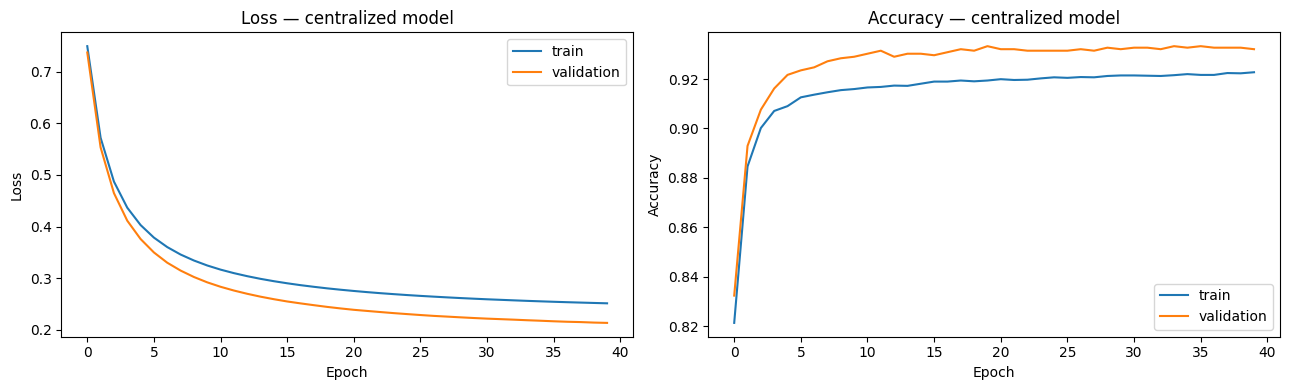

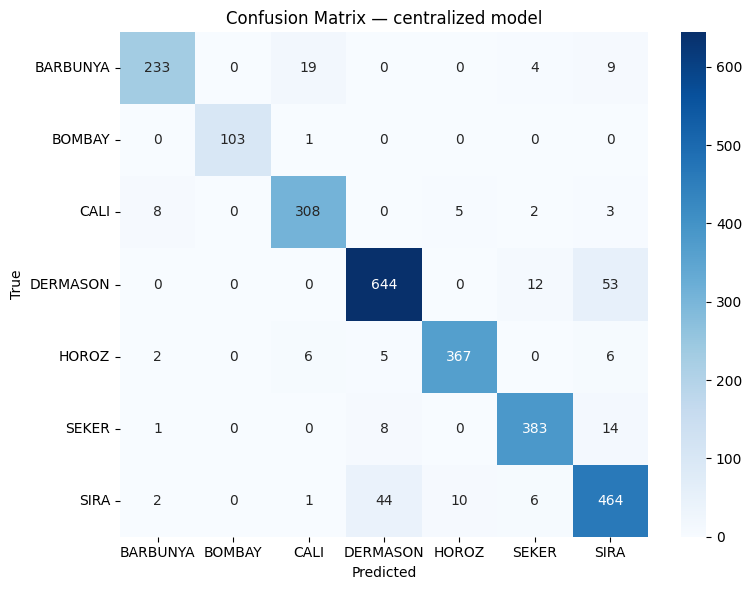

In [16]:
# Графіки навчання центральної моделі
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(central_model.history["loss"], label="train")
axes[0].plot(central_model.history["val_loss"], label="validation")
axes[0].set_title("Loss — centralized model")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(central_model.history["accuracy"], label="train")
axes[1].plot(central_model.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy — centralized model")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, central_test["pred"])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix — centralized model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 4. Розподіл FL Train Pool між клієнтами

Розглянемо два сценарії:

1. **IID** - клієнти мають приблизно однаковий розподіл класів.
2. **Non-IID Dirichlet** - для кожного класу частки між клієнтами генеруються з розподілу Діріхле.

У FedAvg сервер не отримує сирих локальних даних; клієнти передають лише параметри локальних моделей. Це імітація федеративного навчання на одному комп'ютері. 


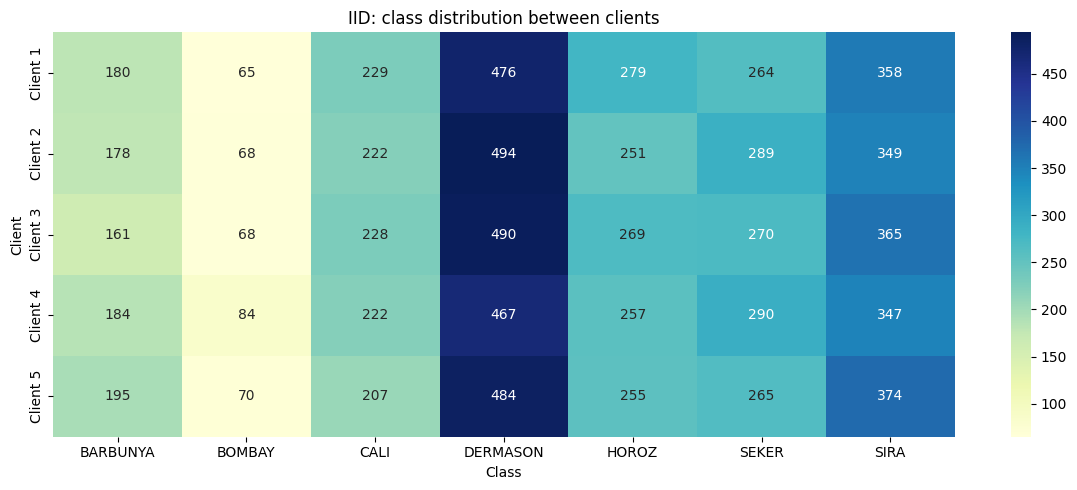

Samples per client: [1851, 1851, 1851, 1851, 1850]
Minimum client size: 1850


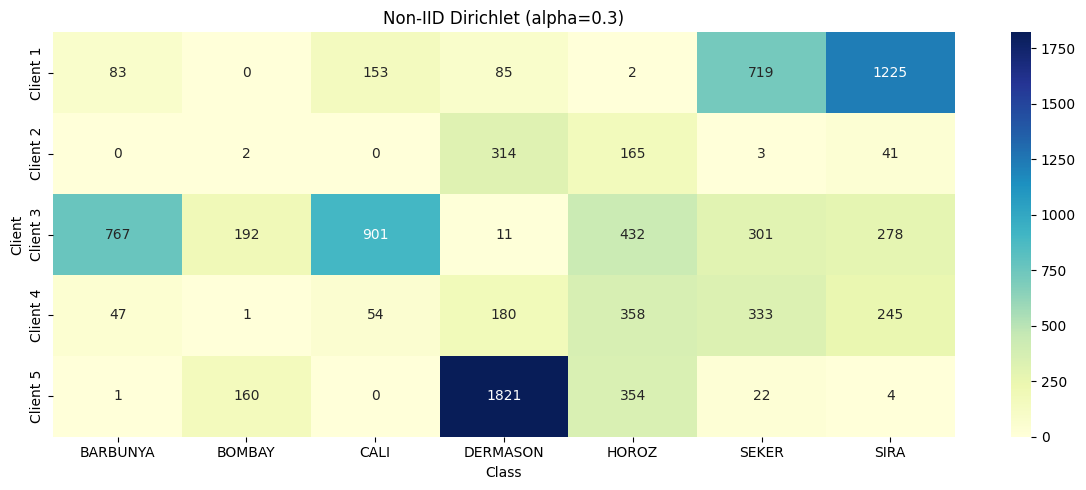

Samples per client: [2267, 525, 2882, 1218, 2362]
Minimum client size: 525


In [ ]:
def split_iid(X, y, n_clients=5, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    chunks = np.array_split(idx, n_clients)
    return [(X[c].copy(), y[c].copy()) for c in chunks]


def split_dirichlet(X, y, n_clients=5, alpha=1.0, seed=42):
    rng = np.random.default_rng(seed)
    client_indices = [[] for _ in range(n_clients)]

    for c in np.unique(y):
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(np.full(n_clients, alpha))
        counts = rng.multinomial(len(idx_c), proportions)

        start = 0
        for k, count in enumerate(counts):
            client_indices[k].extend(idx_c[start:start + count].tolist())
            start += count

    # повторюємо генерацію, якщо якийсь клієнт не отримав прикладів.
    if any(len(idx) == 0 for idx in client_indices):
        return split_dirichlet(X, y, n_clients, alpha, seed + 1)

    clients = []
    for idx in client_indices:
        idx = np.array(idx, dtype=int)
        rng.shuffle(idx)
        clients.append((X[idx].copy(), y[idx].copy()))
    return clients


def client_class_matrix(clients, n_classes):
    mat = np.zeros((len(clients), n_classes), dtype=int)
    for k, (_, yk) in enumerate(clients):
        mat[k] = np.bincount(yk, minlength=n_classes)
    return mat


def plot_client_distribution(clients, title):
    mat = client_class_matrix(clients, len(classes))
    plt.figure(figsize=(12, 5))
    sns.heatmap(mat, annot=True, fmt="d", cmap="YlGnBu",
                xticklabels=classes,
                yticklabels=[f"Client {i+1}" for i in range(len(clients))])
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Client")
    plt.tight_layout()
    plt.show()

    print("Samples per client:", mat.sum(axis=1).tolist())
    print("Minimum client size:", mat.sum(axis=1).min())


iid_clients = split_iid(X_train_s, y_train, n_clients=5, seed=SEED)
noniid_clients = split_dirichlet(X_train_s, y_train, n_clients=5, alpha=0.3, seed=SEED)

plot_client_distribution(iid_clients, "IID: class distribution between clients")
plot_client_distribution(noniid_clients, "Non-IID Dirichlet (alpha=0.3)")


**Висновок щодо розподілу.** IID-розподіл зберігає приблизно глобальні пропорції класів на кожному клієнті. За малого `alpha` у Dirichlet-розподілі клієнти отримують різні пропорції класів; деякі класи можуть бути майже відсутні на окремих клієнтах. Саме це створює Non-IID умови, які ускладнюють FedAvg. fileciteturn0file0L201-L228


## 5. FedAvg

На кожному раунді:
1. сервер передає поточні параметри клієнтам;
2. кожен клієнт навчає локальну модель `E` епох;
3. клієнти повертають параметри;
4. сервер обчислює зважене середнє:




In [18]:
def fedavg(params_list, sample_counts):
    total = np.sum(sample_counts)
    W = sum((n / total) * p["W"] for p, n in zip(params_list, sample_counts))
    b = sum((n / total) * p["b"] for p, n in zip(params_list, sample_counts))
    return {"W": W, "b": b}


def run_federated(clients, X_val, y_val, X_test, y_test,
                  lr, l2, batch_size, local_epochs=5,
                  rounds=20, seed=42):
    n_features = clients[0][0].shape[1]
    n_classes = len(np.unique(y_train))

    global_model = NumpyMulticlassLogisticRegression(
        n_features, n_classes, lr=lr, l2=l2,
        epochs=local_epochs, batch_size=batch_size, seed=seed
    )

    history = {
        "round": [], "val_accuracy": [], "val_macro_f1": [],
        "val_balanced_accuracy": [], "val_log_loss": []
    }

    for rnd in range(1, rounds + 1):
        local_params = []
        sample_counts = []

        for client_id, (Xc, yc) in enumerate(clients):
            local = NumpyMulticlassLogisticRegression(
                n_features, n_classes, lr=lr, l2=l2,
                epochs=local_epochs, batch_size=batch_size,
                seed=seed + rnd * 100 + client_id
            )
            local.set_params(global_model.get_params())
            local.fit(Xc, yc)

            local_params.append(local.get_params())
            sample_counts.append(len(yc))

        new_params = fedavg(local_params, sample_counts)
        global_model.set_params(new_params)

        val_eval = evaluate_model(global_model, X_val, y_val)

        history["round"].append(rnd)
        history["val_accuracy"].append(val_eval["accuracy"])
        history["val_macro_f1"].append(val_eval["macro_f1"])
        history["val_balanced_accuracy"].append(val_eval["balanced_accuracy"])
        history["val_log_loss"].append(val_eval["log_loss"])

    test_eval = evaluate_model(global_model, X_test, y_test)
    return global_model, pd.DataFrame(history), test_eval


In [19]:
# Базовий FedAvg на IID та Non-IID.
fed_iid_model, fed_iid_hist, fed_iid_test = run_federated(
    iid_clients, X_val_s, y_val, X_test_s, y_test,
    lr=float(best["lr"]), l2=float(best["l2"]),
    batch_size=int(best["batch_size"]),
    local_epochs=5, rounds=20, seed=SEED
)

fed_non_model, fed_non_hist, fed_non_test = run_federated(
    noniid_clients, X_val_s, y_val, X_test_s, y_test,
    lr=float(best["lr"]), l2=float(best["l2"]),
    batch_size=int(best["batch_size"]),
    local_epochs=5, rounds=20, seed=SEED
)

for name, result in [
    ("FedAvg IID", fed_iid_test),
    ("FedAvg Non-IID", fed_non_test)
]:
    print(name, {k: round(v, 4) for k, v in result.items()
                 if k in ["accuracy", "macro_f1", "balanced_accuracy", "log_loss"]})


FedAvg IID {'accuracy': 0.9152, 'macro_f1': 0.9274, 'balanced_accuracy': 0.9254, 'log_loss': 0.2702}
FedAvg Non-IID {'accuracy': 0.9104, 'macro_f1': 0.9249, 'balanced_accuracy': 0.9245, 'log_loss': 0.2847}


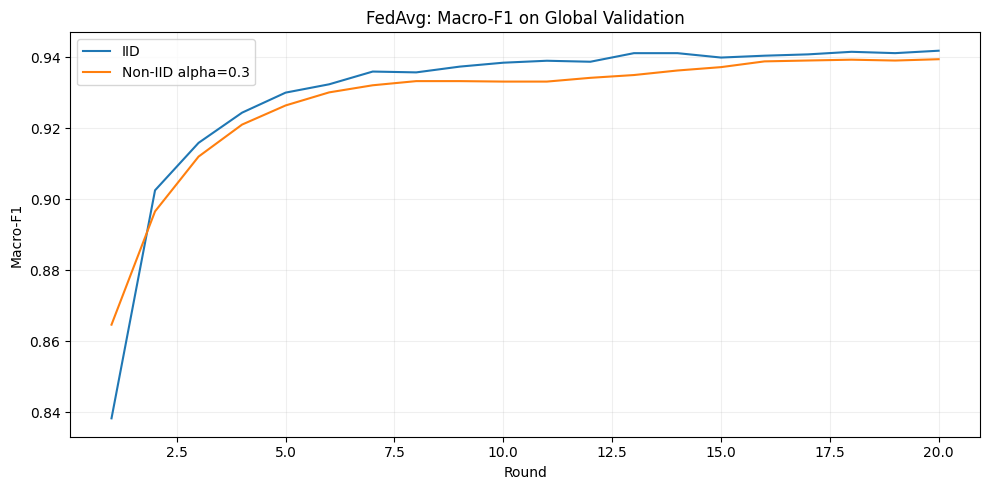

In [20]:
# Графіки навчання FedAvg
plt.figure(figsize=(10, 5))
plt.plot(fed_iid_hist["round"], fed_iid_hist["val_macro_f1"], label="IID")
plt.plot(fed_non_hist["round"], fed_non_hist["val_macro_f1"], label="Non-IID alpha=0.3")
plt.title("FedAvg: Macro-F1 on Global Validation")
plt.xlabel("Round")
plt.ylabel("Macro-F1")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 6. Порівняння локальних, глобальної та централізованої моделей

Для локальних моделей використовується тільки локальна тренувальна вибірка відповідного клієнта. Глобальна модель - результат FedAvg. Централізована модель бачить весь FL Train Pool.

Фінальне порівняння виконується **лише на Global Test**, який не використовувався під час навчання чи підбору параметрів. 


In [21]:
# Навчання локальних моделей для IID-клієнтів та їх оцінка на спільному Global Test.
local_rows = []

for k, (Xc, yc) in enumerate(iid_clients):
    local = NumpyMulticlassLogisticRegression(
        X_train_s.shape[1], len(classes),
        lr=float(best["lr"]), l2=float(best["l2"]),
        epochs=25, batch_size=int(best["batch_size"]), seed=SEED + k
    )
    local.fit(Xc, yc)
    ev = evaluate_model(local, X_test_s, y_test)
    local_rows.append({
        "model": f"Local Client {k+1}",
        "accuracy": ev["accuracy"],
        "macro_f1": ev["macro_f1"],
        "balanced_accuracy": ev["balanced_accuracy"],
        "log_loss": ev["log_loss"]
    })

comparison = pd.DataFrame(local_rows)
comparison = pd.concat([
    comparison,
    pd.DataFrame([{
        "model": "FedAvg IID",
        "accuracy": fed_iid_test["accuracy"],
        "macro_f1": fed_iid_test["macro_f1"],
        "balanced_accuracy": fed_iid_test["balanced_accuracy"],
        "log_loss": fed_iid_test["log_loss"]
    }, {
        "model": "FedAvg Non-IID",
        "accuracy": fed_non_test["accuracy"],
        "macro_f1": fed_non_test["macro_f1"],
        "balanced_accuracy": fed_non_test["balanced_accuracy"],
        "log_loss": fed_non_test["log_loss"]
    }, {
        "model": "Centralized",
        "accuracy": central_test["accuracy"],
        "macro_f1": central_test["macro_f1"],
        "balanced_accuracy": central_test["balanced_accuracy"],
        "log_loss": central_test["log_loss"]
    }])
], ignore_index=True)

display(comparison.round(4))


,model,accuracy,macro_f1,balanced_accuracy,log_loss
0,Local Client 1,0.9049,0.9181,0.9156,0.4049
1,Local Client 2,0.9001,0.9114,0.9079,0.4009
2,Local Client 3,0.9056,0.9173,0.9146,0.3958
3,Local Client 4,0.9038,0.9164,0.9149,0.3999
4,Local Client 5,0.9082,0.9203,0.9166,0.3990
5,FedAvg IID,0.9152,0.9274,0.9254,0.2702
6,FedAvg Non-IID,0.9104,0.9249,0.9245,0.2847
7,Centralized,0.9188,0.9304,0.9282,0.2433


## 7. Експеримент 1 - вплив Non-IID та параметра alpha

Перевіряємо:
- `α = 5` - близько до IID;
- `α = 1` - помірна неоднорідність;
- `α = 0.3` - сильна неоднорідність.

За зменшення `alpha` класи стають менш рівномірно розподіленими між клієнтами. Очікується погіршення FedAvg, оскільки локальні градієнти відображають різні розподіли даних. 


,alpha,accuracy,macro_f1,balanced_accuracy,log_loss
0,5.0,0.9155,0.9280,0.9260,0.2699
1,1.0,0.9148,0.9270,0.9244,0.2734
2,0.3,0.9104,0.9249,0.9245,0.2847


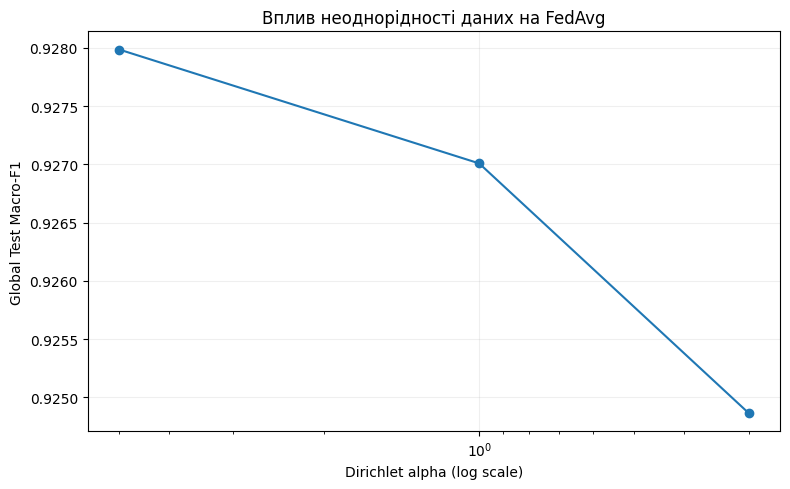

In [22]:
alphas = [5.0, 1.0, 0.3]
alpha_rows = []

for alpha in alphas:
    clients = split_dirichlet(X_train_s, y_train, n_clients=5,
                               alpha=alpha, seed=SEED)
    _, hist, ev = run_federated(
        clients, X_val_s, y_val, X_test_s, y_test,
        lr=float(best["lr"]), l2=float(best["l2"]),
        batch_size=int(best["batch_size"]),
        local_epochs=5, rounds=20, seed=SEED
    )
    alpha_rows.append({
        "alpha": alpha,
        "accuracy": ev["accuracy"],
        "macro_f1": ev["macro_f1"],
        "balanced_accuracy": ev["balanced_accuracy"],
        "log_loss": ev["log_loss"]
    })

alpha_table = pd.DataFrame(alpha_rows)
display(alpha_table.round(4))

plt.figure(figsize=(8, 5))
plt.plot(alpha_table["alpha"], alpha_table["macro_f1"], marker="o")
plt.xscale("log")
plt.gca().invert_xaxis()
plt.title("Вплив неоднорідності даних на FedAvg")
plt.xlabel("Dirichlet alpha (log scale)")
plt.ylabel("Global Test Macro-F1")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Висновок експерименту alpha.** Чим менше `alpha`, тим сильніше Non-IID. Якщо Macro-F1 зменшується разом зі зменшенням `alpha`, це підтверджує, що неоднорідність локальних розподілів ускладнює узгодження локальних моделей. Глобальна модель може бути гіршою за централізовану, оскільки централізоване навчання безпосередньо бачить весь тренувальний розподіл. 


## 8. Експеримент 2 - вплив кількості локальних епох E

Перевіряємо `E = 1, 5, 10`. На Non-IID даних велика кількість локальних епох може посилити **client drift** - локальні моделі надто сильно відхиляються від спільної глобальної моделі. 


,E,accuracy,macro_f1,balanced_accuracy,log_loss
0,1,0.9019,0.9155,0.9149,0.4256
1,5,0.9104,0.9249,0.9245,0.2847
2,10,0.9144,0.9288,0.9284,0.2574


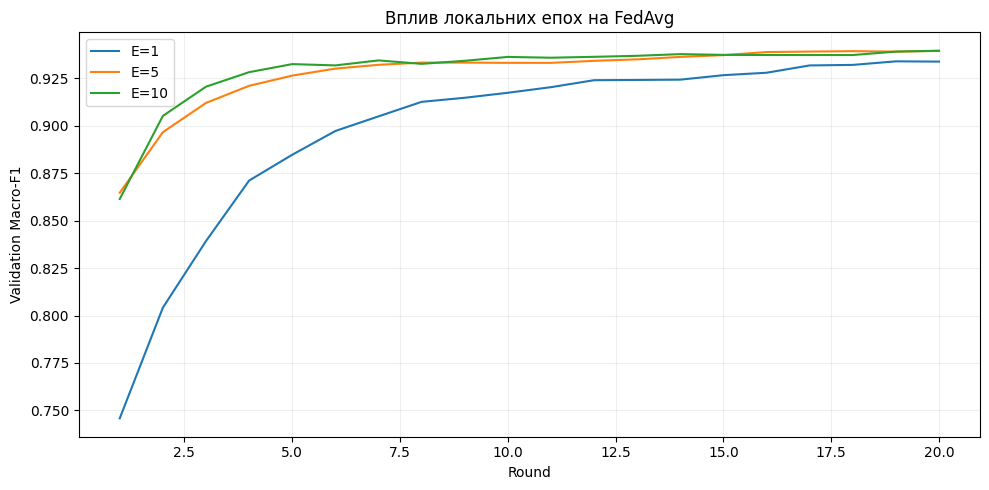

In [23]:
E_values = [1, 5, 10]
E_rows = []
E_histories = {}

# Для чесного порівняння використовуємо один і той самий Non-IID розподіл.
fixed_clients = split_dirichlet(
    X_train_s, y_train, n_clients=5, alpha=0.3, seed=SEED
)

for E in E_values:
    model_E, hist_E, ev_E = run_federated(
        fixed_clients, X_val_s, y_val, X_test_s, y_test,
        lr=float(best["lr"]), l2=float(best["l2"]),
        batch_size=int(best["batch_size"]),
        local_epochs=E, rounds=20, seed=SEED
    )
    E_histories[E] = hist_E
    E_rows.append({
        "E": E,
        "accuracy": ev_E["accuracy"],
        "macro_f1": ev_E["macro_f1"],
        "balanced_accuracy": ev_E["balanced_accuracy"],
        "log_loss": ev_E["log_loss"]
    })

E_table = pd.DataFrame(E_rows)
display(E_table.round(4))

plt.figure(figsize=(10, 5))
for E in E_values:
    plt.plot(E_histories[E]["round"],
             E_histories[E]["val_macro_f1"],
             label=f"E={E}")
plt.title("Вплив локальних епох на FedAvg")
plt.xlabel("Round")
plt.ylabel("Validation Macro-F1")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Висновок експерименту E.** `E=1` робить оновлення клієнтів ближчими до глобальної моделі, але потребує більше раундів. Збільшення `E` пришвидшує локальне навчання, проте на Non-IID даних може посилити client drift. Тому оптимальне значення `E` є компромісом між локальною обчислювальною ефективністю та стабільністю глобальної моделі.


## 9. Відповіді на теоретичні питання

**1. Чому для багатокласової класифікації використовують softmax?**  
Softmax перетворює набір logits у ймовірності всіх класів, які для одного об'єкта сумуються до 1. Це природно для взаємовиключних класів.

**2. Чому cross-entropy є природною функцією втрат?**  
Вона безпосередньо вимірює різницю між правильною one-hot-міткою та розподілом ймовірностей моделі. Для правильної відповіді вона стимулює модель збільшувати ймовірність правильного класу.

**3. Чим Ridge відрізняється від Lasso?**  
Ridge використовує L2-штраф \(lambda|W\|_2^2/2\) і переважно зменшує ваги. Lasso використовує L1-штраф \(lambda|W\|_1\) і може зануляти окремі ваги, виконуючи своєрідний відбір ознак.

**4. Чому bias b зазвичай не регуляризують?**  
Bias відповідає за загальний зсув decision boundary. Регуляризація ваг корисна для контролю складності залежності від ознак, тоді як штрафування bias може непотрібно обмежувати положення межі.

**5. Що таке Data Leakage?**  
Це ситуація, коли інформація з validation/test або майбутньої інформації потрапляє в процес навчання. Наприклад, обчислення mean/std на всьому датасеті до split робить тестову статистику доступною моделі.

**6. Чому тест не можна використовувати для підбору гіперпараметрів?**  
Тоді тест перестає бути незалежною оцінкою узагальнювальної здатності. Повторний підбір за test фактично адаптує модель до тестової вибірки.

**7. Чому параметри масштабування навчаються лише на train?**  
Mean і standard deviation є параметрами, отриманими з даних. Якщо використати validation/test, виникає Data Leakage.

**8. Що таке федеративне навчання та його переваги?**  
Це схема, де локальні учасники навчають моделі на своїх даних, а сервер агрегує оновлення. Головна перевага — сирі локальні дані не потрібно централізовано передавати серверу.

**9. Чому сервер не повинен отримувати сирі дані клієнтів?**  
Це зберігає локальність даних і зменшує потребу централізувати потенційно чутливу інформацію.

**10. Чому FedAvg зважує за кількістю прикладів?**  
Клієнт із більшою тренувальною вибіркою має більше інформації про загальний train pool, тому його оновлення повинно мати пропорційно більший внесок.

**11. Що буде без зважування?**  
Кожен клієнт матиме однаковий вплив незалежно від розміру його датасету. Малий клієнт може непропорційно сильно впливати на глобальну модель.

**12. Що таке Non-IID дані?**  
Це локальні дані, розподіл яких між клієнтами відрізняється від глобального розподілу. Наприклад, один клієнт може мати переважно один клас.

**13. Чому FL може погіршуватися на Non-IID?**  
Локальні моделі оптимізують різні розподіли. Їхні градієнти можуть мати різні напрямки, тому просте усереднення не завжди дає оптимальне глобальне оновлення.

**14. Що таке client drift?**  
Це надмірне відхилення локальної моделі від глобальної через локальне навчання на неоднорідних даних.

**15. Як кількість локальних епох впливає на глобальну модель?**  
Зі збільшенням `E` локальна модель сильніше адаптується до даних клієнта. На Non-IID це може збільшувати client drift.

**16. Чи може глобальна модель бути гіршою за централізовану?**  
Так. FedAvg працює через локальні оновлення та їх агрегацію, тоді як централізована модель оптимізується безпосередньо на всьому FL Train Pool.

**17. Які метрики краще використовувати при дисбалансі?**  
Окрім accuracy доцільно використовувати macro-F1 та balanced accuracy, оскільки вони не дозволяють великому класу повністю домінувати в оцінці. Log-loss додатково оцінює якість прогнозованих ймовірностей.


## 10.Висновок

У роботі реалізовано повний цикл багатокласової класифікації та федеративного навчання на Dry Bean Dataset. Спочатку дані було досліджено та розділено на Global Test, Global Validation і FL Train Pool без використання тестової вибірки під час підготовки. Після цього виконано відбір ознак і стандартизацію.

Багатокласову логістичну регресію реалізовано самостійно засобами NumPy: softmax, cross-entropy з Ridge-регуляризацією, аналітичні градієнти та mini-batch SGD. Далі модель використано у централізованому та федеративному режимах.

Для федеративного навчання реалізовано IID та Non-IID Dirichlet-розподіли, а параметри локальних моделей агреговано методом FedAvg із вагами, пропорційними кількості тренувальних прикладів клієнта. Експерименти з `alpha` демонструють вплив неоднорідності даних, а експерименти з `E` - вплив кількості локальних епох і client drift.

Таким чином, федеративне навчання дозволяє навчати спільну модель без централізації сирих клієнтських даних, але якість FedAvg залежить від неоднорідності локальних вибірок та параметрів локального навчання.
